In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


In [2]:
mode = 'ms'

mag_range = [[-0.4,1.65],[-1,18]]
mag_step = [0.02,0.2]
mag_smooth = [0.06,0.8]

if mode == 'ms+wd':
    hess_ref = np.loadtxt('data/hess/hess_tot.txt')
    hess = np.loadtxt('output/hess_m2d/padova/hess_tot.txt')
elif mode == 'ms':
    hess_ref = np.loadtxt('data/hess/hess_ms.txt')
    hess = np.loadtxt('output/hess_m2d/padova/hess_ms.txt')
else:
    hess_ref = np.loadtxt('data/hess/hess_wd.txt')
    hess = np.loadtxt('output/hess_m2d/padova/hess_wd.txt')

In [ ]:
# Hyperparameters

eps = 0.1
min_count = 1e-2
var_floor = 1e-2

In [4]:
D = hess_ref
M = hess

# Plottable version of Dp
Dp_im = D.copy()
Dp_im += eps
i1, i2 = np.where((M <= min_count)) # (D <= min_count) & 
i1_r, i2_r = np.where((M >= min_count)) # (D >= min_count) | 
Dp_im[i1,i2] = np.nan

# Plottable version of Mp
Mp_im = M.copy()
Mp_im += eps
Mp_im = np.clip(Mp_im, 1e-12, None)
Mp_im[i1,i2] = np.nan


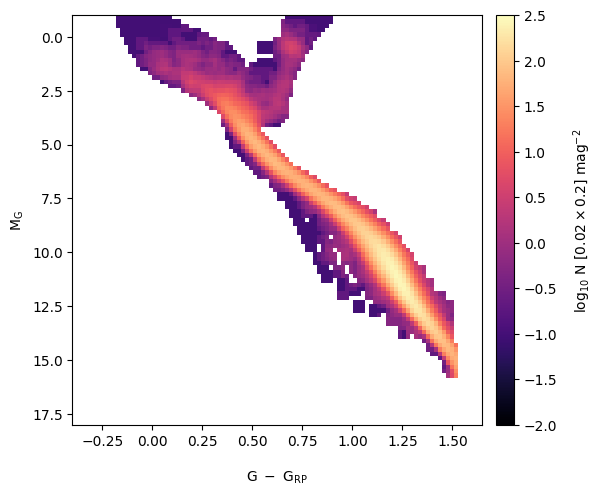

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

im = ax.imshow(np.log10(Dp_im),
          interpolation=None,
          cmap=mpl.colormaps['magma'],
          extent=[mag_range[0][0],mag_range[0][1],mag_range[1][1],mag_range[1][0]],
          vmin=-2,
          vmax=2.5
          )
ax.set_aspect(abs((mag_range[0][1]-mag_range[0][0])/(mag_range[1][1]-mag_range[1][0])))
ax.set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$',labelpad=15)
ax.set_ylabel(r'$\mathrm{M_G}$')

fig.subplots_adjust(left=0.05,wspace=0.05,right=0.8,top=0.93)
pos = ax.get_position()
cax = fig.add_axes([pos.x0+pos.width+0.02,pos.y0,0.025,pos.height])
cbar = fig.colorbar(im,cax=cax,orientation='vertical')
cbar.set_label(r'$\mathrm{log_{10} \ N \ [' + str(mag_step[0]) +
               r'\times' + str(mag_step[1]) + r'] \ mag^{-2}}$',labelpad=10)
plt.show()


In [6]:
r_im = np.log10(Dp_im) - np.log10(Mp_im)
#r = Dp - Mp

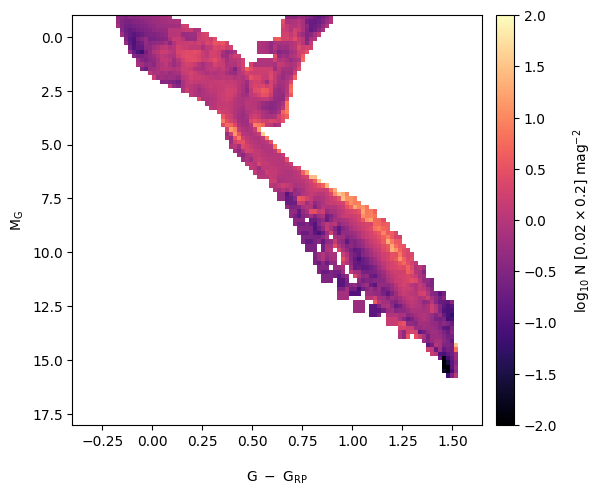

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

im = ax.imshow(r_im,
          interpolation=None,
          cmap=mpl.colormaps['magma'],
          extent=[mag_range[0][0],mag_range[0][1],mag_range[1][1],mag_range[1][0]],
          vmin=-2,
          vmax=2
          )
ax.set_aspect(abs((mag_range[0][1]-mag_range[0][0])/(mag_range[1][1]-mag_range[1][0])))
ax.set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$',labelpad=15)
ax.set_ylabel(r'$\mathrm{M_G}$')

fig.subplots_adjust(left=0.05,wspace=0.05,right=0.8,top=0.93)
pos = ax.get_position()
cax = fig.add_axes([pos.x0+pos.width+0.02,pos.y0,0.025,pos.height])
cbar = fig.colorbar(im,cax=cax,orientation='vertical')
cbar.set_label(r'$\mathrm{log_{10} \ N \ [' + str(mag_step[0]) +
               r'\times' + str(mag_step[1]) + r'] \ mag^{-2}}$',labelpad=10)
plt.show()

In [8]:
M_im = M.copy()
M_im[:,:] = np.nan
M_im[i1_r,i2_r] = M[i1_r,i2_r]

var_y_im = M_im / ((np.log(10)**2) * (Mp_im**2))
var_y_im = np.maximum(var_y_im, var_floor)

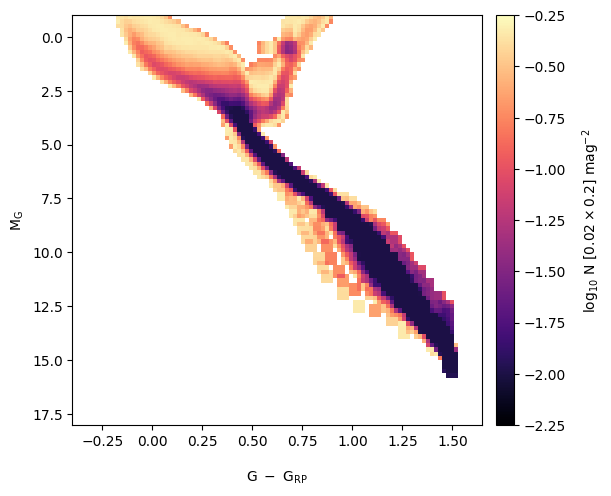

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
im = ax.imshow(np.log10(var_y_im),
          interpolation=None,
          cmap=mpl.colormaps['magma'],
          extent=[mag_range[0][0],mag_range[0][1],mag_range[1][1],mag_range[1][0]],
          vmin=-2.25,
          vmax=-0.25
          )
ax.set_aspect(abs((mag_range[0][1]-mag_range[0][0])/(mag_range[1][1]-mag_range[1][0])))
ax.set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$',labelpad=15)
ax.set_ylabel(r'$\mathrm{M_G}$')

fig.subplots_adjust(left=0.05,wspace=0.05,right=0.8,top=0.93)
pos = ax.get_position()
cax = fig.add_axes([pos.x0+pos.width+0.02,pos.y0,0.025,pos.height])
cbar = fig.colorbar(im,cax=cax,orientation='vertical')
cbar.set_label(r'$\mathrm{log_{10} \ N \ [' + str(mag_step[0]) +
               r'\times' + str(mag_step[1]) + r'] \ mag^{-2}}$',labelpad=10)
plt.show()

In [10]:
per_bin_im = r_im*r_im / var_y_im

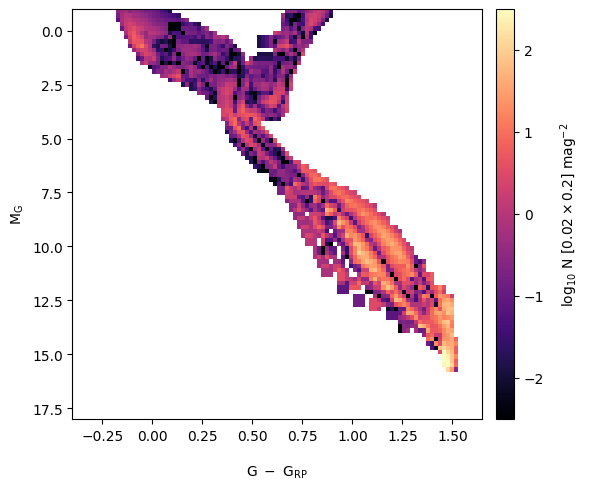

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
im = ax.imshow(np.log10(per_bin_im),
          interpolation=None,
          cmap=mpl.colormaps['magma'],
          extent=[mag_range[0][0],mag_range[0][1],mag_range[1][1],mag_range[1][0]],
          vmin=-2.5,
          vmax=2.5
          )
ax.set_aspect(abs((mag_range[0][1]-mag_range[0][0])/(mag_range[1][1]-mag_range[1][0])))
ax.set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$',labelpad=15)
ax.set_ylabel(r'$\mathrm{M_G}$')

fig.subplots_adjust(left=0.05,wspace=0.05,right=0.8,top=0.93)
pos = ax.get_position()
cax = fig.add_axes([pos.x0+pos.width+0.02,pos.y0,0.025,pos.height])
cbar = fig.colorbar(im,cax=cax,orientation='vertical')
cbar.set_label(r'$\mathrm{log_{10} \ N \ [' + str(mag_step[0]) +
               r'\times' + str(mag_step[1]) + r'] \ mag^{-2}}$',labelpad=10)
plt.show()

In [12]:
D_im = D.copy()
D_im[:,:] = np.nan
D_im[i1_r,i2_r] = D[i1_r,i2_r]

w_scale = Dp_im * np.log10(D_im + 1)
#w_scale = np.log10(D_im + 1)
#w_scale = Dp_im**2 
#w_scale = np.array([1])
weights = w_scale / np.nansum(w_scale)  # sums to 1

per_bin_w_im = weights * per_bin_im

/tmp/ipykernel_4011410/2402120652.py:2: RuntimeWarning: divide by zero encountered in log10
  im = ax.imshow(np.log10(weights), # np.log10(per_bin_w_im)


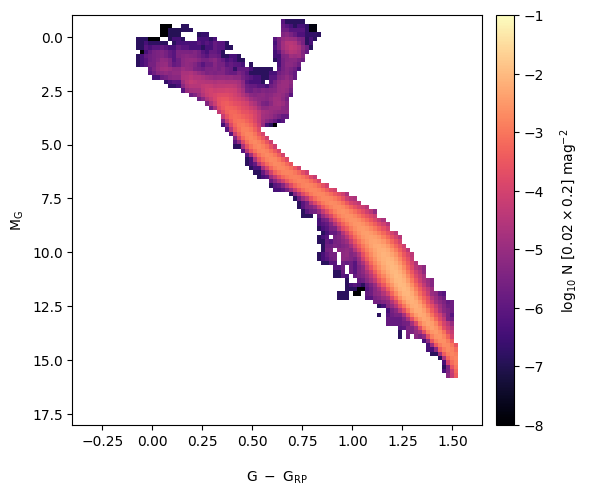

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
im = ax.imshow(np.log10(weights), # np.log10(per_bin_w_im)
          interpolation=None,
          cmap=mpl.colormaps['magma'],
          extent=[mag_range[0][0],mag_range[0][1],mag_range[1][1],mag_range[1][0]],
          vmin=-8,
          vmax=-1
          )
ax.set_aspect(abs((mag_range[0][1]-mag_range[0][0])/(mag_range[1][1]-mag_range[1][0])))
ax.set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$',labelpad=15)
ax.set_ylabel(r'$\mathrm{M_G}$')

fig.subplots_adjust(left=0.05,wspace=0.05,right=0.8,top=0.93)
pos = ax.get_position()
cax = fig.add_axes([pos.x0+pos.width+0.02,pos.y0,0.025,pos.height])
cbar = fig.colorbar(im,cax=cax,orientation='vertical')
cbar.set_label(r'$\mathrm{log_{10} \ N \ [' + str(mag_step[0]) +
               r'\times' + str(mag_step[1]) + r'] \ mag^{-2}}$',labelpad=10)
plt.show()

In [14]:
- 0.5 * np.nansum(np.nansum(per_bin_w_im))

np.float64(-3.2688956457250025)

In [15]:
per_bin_w_im.sum()

np.float64(nan)

In [16]:
x_col = np.arange(mag_range[0][0]+mag_step[0]/2,mag_range[0][1]-mag_step[0]/2,mag_step[0])
y_mag = np.arange(mag_range[1][0]+mag_step[1]/2,mag_range[1][1]+mag_step[1]/2,mag_step[1])

In [49]:

# Plottable version of Dp
Dp_im = D.copy()
Dp_im += eps
i1, i2 = np.where((M <= min_count) & (D <= min_count)) # (D <= min_count) & 
Dp_im[i1,i2] = np.nan

# Plottable version of Mp
Mp_im = M.copy()
Mp_im += eps
Mp_im[i1,i2] = np.nan


hx_d = np.nansum(Dp_im,axis=0)
hy_d = np.nansum(Dp_im,axis=1)

hx_m = np.nansum(Mp_im,axis=0)
hy_m = np.nansum(Mp_im,axis=1)

hx_dc = np.cumsum(hx_d)/hx_d.sum()
hy_dc = np.cumsum(hy_d)/hy_d.sum()

hx_mc = np.cumsum(hx_m)/hx_m.sum()
hy_mc = np.cumsum(hy_m)/hy_m.sum()

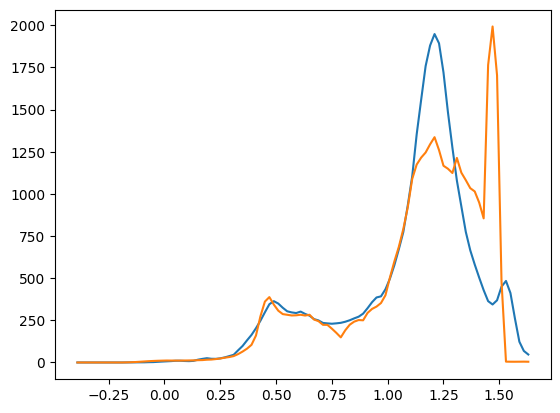

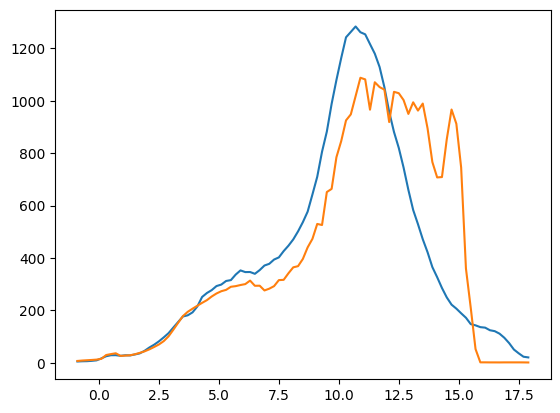

In [33]:
plt.figure()
plt.plot(x_col,hx_d)
plt.plot(x_col,hx_m)


plt.figure()
plt.plot(y_mag,hy_d)
plt.plot(y_mag,hy_m)

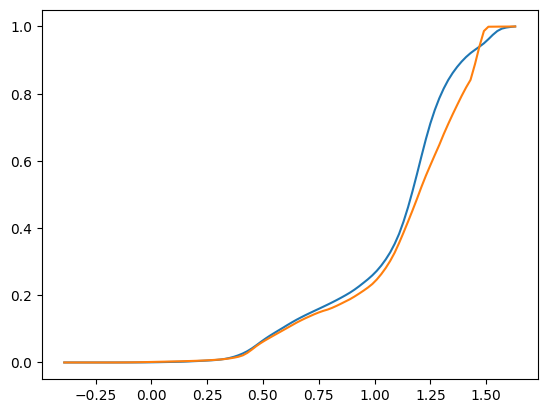

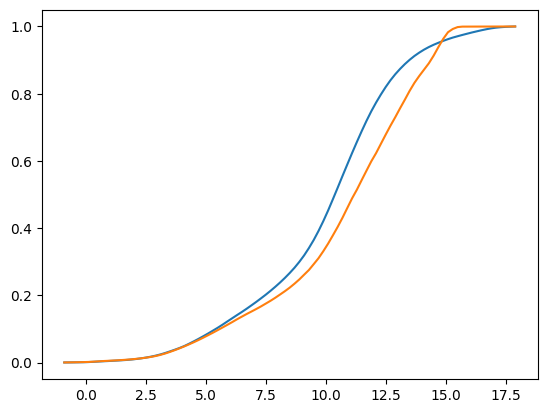

In [34]:
plt.figure()
plt.plot(x_col,hx_dc)
plt.plot(x_col,hx_mc)

plt.figure()
plt.plot(y_mag,hy_dc)
plt.plot(y_mag,hy_mc)

-0.277658795193997


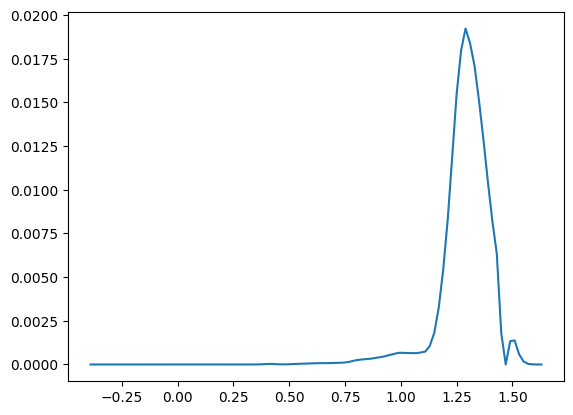

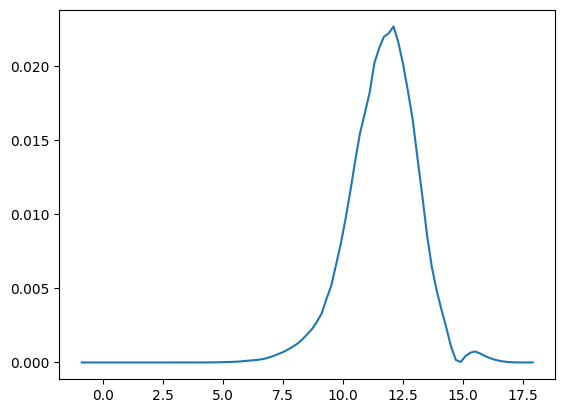

In [35]:
w_x = hx_d*np.log10(hx_d + 1)
w_y = hy_d*np.log10(hy_d + 1)

w_x /= w_x.sum()
w_y /= w_y.sum()

logl_xc = (hx_dc - hx_mc)**2
logl_yc = (hy_dc - hy_mc)**2
 
logl_c = -0.5 * sum(logl_xc) -0.5 * sum(logl_yc)
print(logl_c)

plt.figure()
plt.plot(x_col,logl_xc)

plt.figure()
plt.plot(y_mag,logl_yc)


-3140.2791499420396
-2723.3795013037493


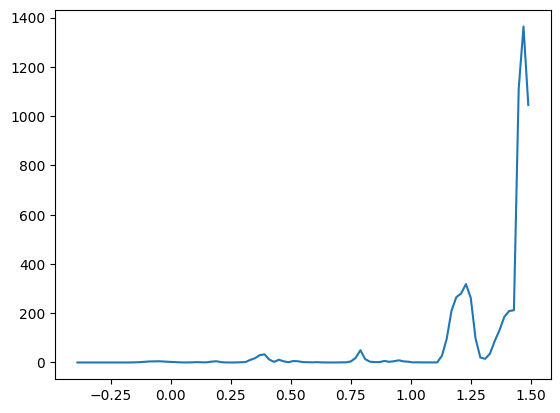

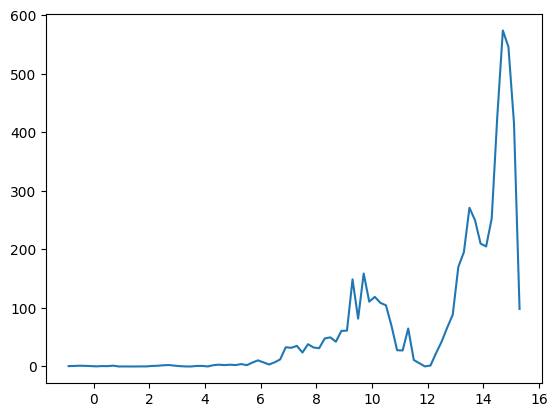

In [50]:
w = np.array([1.])
#w = np.log10(hx_d + 1)
#w = hx_d
#w = hx_d * np.log10(hx_d + 1)
#w = hx_d**2

w /= np.nansum(w)
r2 = (hx_d - hx_m)**2
var_x = hx_m # ((hx_m + 1) / ((np.log(10)**2) * ((hx_m + 1)**2)))
var_x = np.maximum(var_x, var_floor)
pb_x = r2 / var_x
logl_x = w*pb_x

# --------

w = np.array([1.])
#w = np.log10(hy_d + 1)
#w = hy_d
#w = hx_d * np.log10(hx_d + 1)
#w = hx_d**2

w /= np.nansum(w)
r2 = (hy_d - hy_m)**2
var_y = hy_m # ((hy_m + 1) / ((np.log(10)**2) * ((hy_m + 1)**2)))
var_y = np.maximum(var_y, var_floor)
pb_y = r2 / var_y
logl_y = w*pb_y

plt.figure()
plt.plot(x_col[:95],logl_x[:95])

plt.figure()
plt.plot(y_mag[:82],logl_y[:82])

print(-0.5*np.nansum(logl_x[:95]))
print(-0.5*np.nansum(logl_y[:82]))

In [43]:
y_mag[82]

np.float64(15.500000000000005)

In [ ]:
def loglike_masked_combined(D, M, eps=0.1, min_count=1e-2):
    # keep bins with signal in either data or model
    #mask = (D >= min_count) | (M >= min_count)
    mask = (M >= min_count)
    if not np.any(mask):
        return -np.inf   # or a benign value

    Dp = D[mask] + eps
    Mp = M[mask] + eps

    # Plottable version of Dp
    Dp_im = D.copy()
    Dp_im += eps
    i1, i2 = np.where((M <= min_count)) 
    Dp_im[i1,i2] = np.nan

    # Plottable version of Mp
    Mp_im = M.copy()
    Mp_im += eps
    Mp_im[i1,i2] = np.nan

    logl_xc = (hx_dc - hx_mc)**2
    logl_yc = (hy_dc - hy_mc)**2
    
    hx_d = np.nansum(Dp_im,axis=0)
    hy_d = np.nansum(Dp_im,axis=1)

    hx_m = np.nansum(Mp_im,axis=0)
    hy_m = np.nansum(Mp_im,axis=1)

    hx_dc = np.cumsum(hx_d)/hx_d.sum()
    hy_dc = np.cumsum(hy_d)/hy_d.sum()

    hx_mc = np.cumsum(hx_m)/hx_m.sum()
    hy_mc = np.cumsum(hy_m)/hy_m.sum()

    logL_shape = -0.5 * sum(logl_xc) -0.5 * sum(logl_yc)

    sigma_rel = 0.02
    diff_rel =  (Dp.sum() - Mp.sum()) / Dp.sum()
    logL_count = -0.5 * (diff_rel / sigma_rel)**2

    fw1 = 1 # 1e-3
    fw2 = 1 # 1e-2 # larger contribution from logL_count! 
    scale = 0 # -5000
    logL = fw1*logL_shape + fw2*(logL_count + scale)

    print(round(M.sum(),1), '\t', 
          round(fw1*logL_shape,3), '\t', 
          round(fw2*(logL_count + scale),3), '\t', 
          round(logL,3)
          )

    return logL

In [153]:
nd = np.nansum(np.nansum(Dp_im)) 
nm = np.nansum(np.nansum(Mp_im)) 

logl_count = -0.5 * (np.log10(nd) - np.log10(nm))**2/np.log10(0.02)**2
print(logl_count)

-0.0006893995784921659


In [158]:
np.log(nd)

np.float64(10.514418066265444)

In [159]:
np.log(nd)

np.float64(10.514418066265444)